In [2]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'seaborn', 'scikit-learn', '-q'])

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')

PyTorch : 2.12.0+cu130
Device  : cpu


In [3]:
# Synthetic ECG Dataset Generation

FS = 360  # Hz Matches MIT-BIH standard

# ECG beat template based on Gaussian functions to simulate PQRST complex
def ecg_beat_template(n=100):
    """Single PQRST complex as a 100-sample array."""
    t = np.linspace(0, 1, n)
    p =  0.15 * np.exp(-((t - 0.20)**2) / 0.0015)
    q = -0.10 * np.exp(-((t - 0.38)**2) / 0.0003)
    r =  1.00 * np.exp(-((t - 0.42)**2) / 0.0002)
    s = -0.20 * np.exp(-((t - 0.46)**2) / 0.0003)
    tw=  0.25 * np.exp(-((t - 0.62)**2) / 0.002)
    return (p + q + r + s + tw).astype(np.float32)

# Precompute the beat template
BEAT = ecg_beat_template()

# Class definitions
CLASS_INFO = {
    0: {'name': 'Normal',      'bpm_range': (55,  90),  'color': 'steelblue'},
    1: {'name': 'Tachycardia', 'bpm_range': (100, 160), 'color': 'tomato'},
    2: {'name': 'Bradycardia', 'bpm_range': (30,  50),  'color': 'seagreen'},
}

# Generate synthetic ECG signal with given BPM, length, and noise
def generate_ecg(bpm, seq_len=360, noise_std=0.04, rng=None):
    if rng is None:
        # Use a local RNG instance to avoid affecting global state
        rng = np.random.default_rng()

    # Calculate samples per beat based on BPM
    samples_per_beat = int(60.0 / bpm * FS)
    sig = np.zeros(seq_len, dtype=np.float32)
    pos = rng.integers(0, max(1, samples_per_beat // 3))

    # Insert beats with some jitter to simulate natural variability
    while pos < seq_len:
        end = min(pos + len(BEAT), seq_len)
        sig[pos:end] += BEAT[:end - pos]
        jitter = rng.integers(-int(0.02 * FS), int(0.02 * FS) + 1)
        pos += samples_per_beat + jitter

    # Add Gaussian noise to the signal
    sig += rng.normal(0, noise_std, seq_len).astype(np.float32)
    return sig

# Build dataset with specified number of samples per class, sequence length, and random seed
def build_dataset(n_per_class=800, seq_len=360, seed=SEED):
    # Use a local RNG instance to ensure reproducibility without affecting global state
    rng = np.random.default_rng(seed)
    X, y = [], []

    for label, info in CLASS_INFO.items():
        # Sample BPM values uniformly within the specified range for each class
        lo, hi = info['bpm_range']

        for _ in range(n_per_class):
            # Sample BPM for this instance
            bpm = rng.uniform(lo, hi)
            X.append(generate_ecg(bpm, seq_len, rng=rng))
            y.append(label)

    # Shuffle the dataset to ensure random order
    X   = np.stack(X)[:, np.newaxis, :]  # (N, 1, 360)
    y   = np.array(y, dtype=np.int64)
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

# Generate the dataset and print its shape and class distribution
X, y = build_dataset()
print(f'X={X.shape}  y={y.shape}')
print(f'Classes: {np.bincount(y)}')


X=(2400, 1, 360)  y=(2400,)
Classes: [800 800 800]


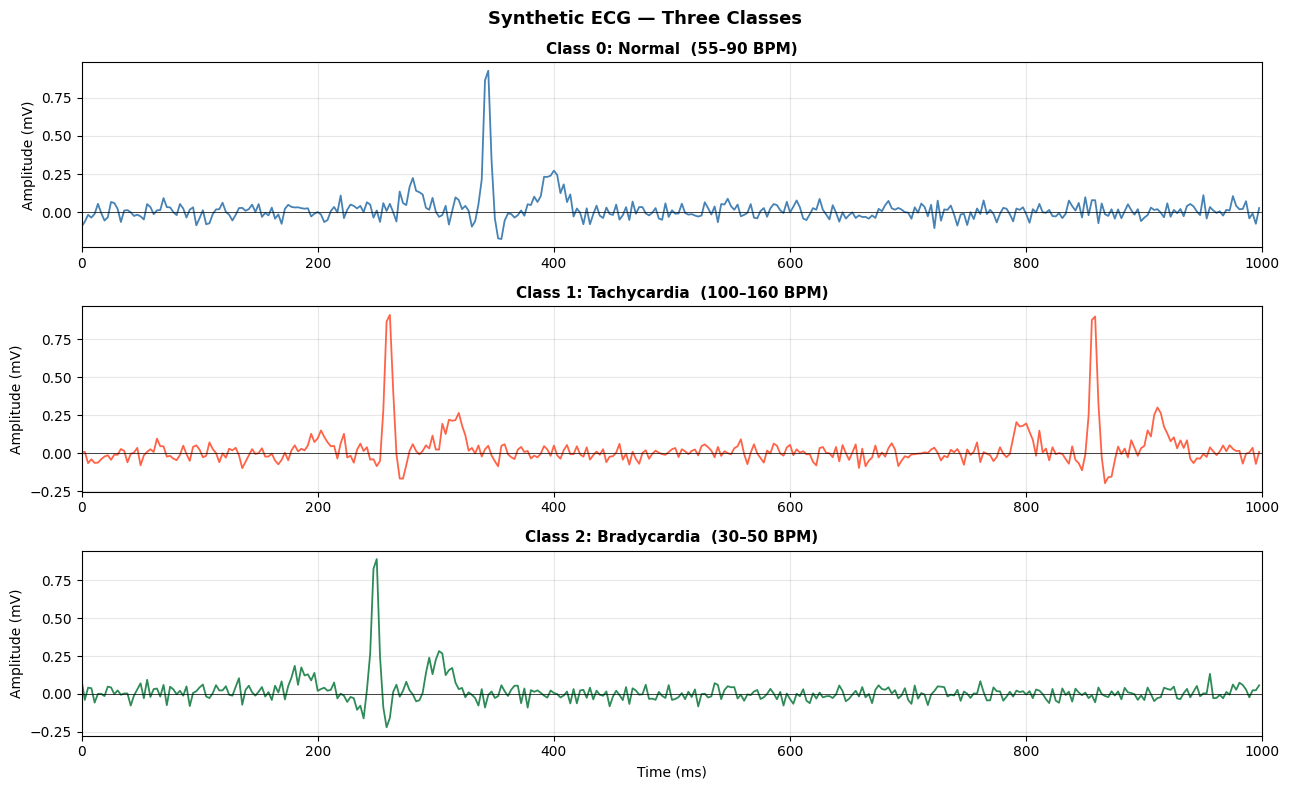

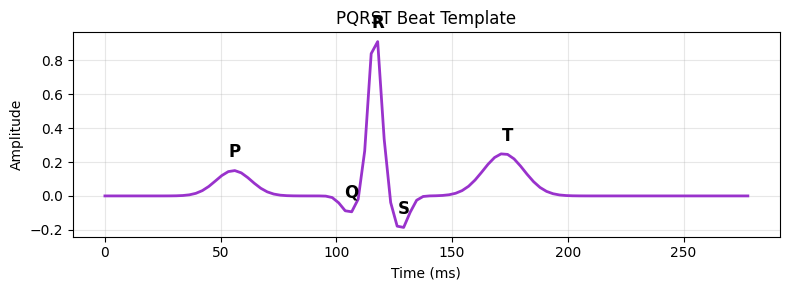

In [4]:
# Visualize sample ECG signals from each class

fig, axes = plt.subplots(3, 1, figsize=(13, 8))
t_axis = np.arange(360) / FS * 1000  # ms

# Plot one sample from each class with appropriate titles and formatting
for label, info in CLASS_INFO.items():
    idx = np.where(y == label)[0][0]
    lo, hi = info['bpm_range']
    axes[label].plot(t_axis, X[idx, 0], color=info['color'], linewidth=1.3)
    axes[label].set_title(f"Class {label}: {info['name']}  ({lo}–{hi} BPM)",fontsize=11, fontweight='bold')
    axes[label].set_ylabel('Amplitude (mV)')
    axes[label].set_xlim(0, 1000)
    axes[label].grid(alpha=0.3)
    axes[label].axhline(0, color='black', linewidth=0.5)

axes[2].set_xlabel('Time (ms)')
plt.suptitle('Synthetic ECG — Three Classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# PQRST template closeup
fig2, ax = plt.subplots(figsize=(8, 3))
t_beat = np.linspace(0, len(BEAT) / FS * 1000, len(BEAT))
ax.plot(t_beat, BEAT, color='darkorchid', linewidth=2)

# Annotate PQRST points on the beat template
for lbl, pos in [('P',20),('Q',38),('R',42),('S',46),('T',62)]:
    xi = int(pos / 100 * len(BEAT))
    ax.annotate(lbl, xy=(t_beat[xi], BEAT[xi]), fontsize=12, fontweight='bold', ha='center', xytext=(0, 10), textcoords='offset points')

# Final formatting for the beat template plot
ax.set_title('PQRST Beat Template')
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Amplitude'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
# Prepare PyTorch Datasets and DataLoaders for training, validation, and testing

# Define a custom Dataset class to wrap the ECG data for PyTorch
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Split the dataset into training, validation, and test sets (70/15/15) with a fixed random seed for reproducibility
N       = len(y)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
n_test  = N - n_train - n_val

# Create the full dataset and then split it into train/val/test subsets using random_split with a fixed seed for reproducibility
dataset = ECGDataset(X, y)
train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(SEED))

# Create DataLoaders for each subset with appropriate batch sizes and shuffling for training
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=64)
test_dl  = DataLoader(test_ds,  batch_size=64)

# Fetch one batch from the training DataLoader and print dataset sizes and batch shapes to verify everything is set up correctly
xb, yb = next(iter(train_dl))
print(f'Train={len(train_ds)}  Val={len(val_ds)}  Test={len(test_ds)}')
print(f'Batch: X={xb.shape}  y={yb.shape}')


Train=1680  Val=360  Test=360
Batch: X=torch.Size([64, 1, 360])  y=torch.Size([64])


In [6]:
# TCN Model Definition

# CausalConv1d ensures that the output at time t only depends on inputs at time <= t, preventing future leakage.
class CausalConv1d(nn.Module):
    """output[t] depends only on input[<=t] — no future leakage."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.pad  = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size,
                              dilation=dilation, padding=self.pad)

    # Remove the extra padding at the end to ensure causality
    def forward(self, x):
        out = self.conv(x)
        return out[:, :, :-self.pad] if self.pad > 0 else out

# TCNBlock consists of two dilated causal convolutional layers with batch normalization, ReLU activation, and a residual skip connection.
class TCNBlock(nn.Module):
    """Two dilated causal convs + residual skip connection."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch,  out_ch, kernel_size, dilation)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.relu  = nn.ReLU()
        self.res   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return self.relu(out + self.res(x))

# ECG_TCN is the main model class that stacks multiple TCNBlocks with increasing dilation, 
# followed by global average pooling and a linear head for classification.
class ECG_TCN(nn.Module):
    def __init__(self, in_ch=1, num_classes=3, channels=None, kernel_size=5):
        super().__init__()

        if channels is None:
            channels = [32, 32, 64, 64]

        blocks = []

        for i, ch in enumerate(channels):
            ic = in_ch if i == 0 else channels[i - 1]
            blocks.append(TCNBlock(ic, ch, kernel_size, dilation=2**i))

        self.network = nn.Sequential(*blocks)
        self.pool    = nn.AdaptiveAvgPool1d(1)
        self.head    = nn.Linear(channels[-1], num_classes)

    def forward(self, x):
        out = self.network(x)               # (B, 64, 360)
        out = self.pool(out).squeeze(-1)    # (B, 64)
        return self.head(out)               # (B, 3)

# Instantiate the model, move it to the appropriate device, and print the number of parameters and model architecture.
model = ECG_TCN().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)


Parameters: 90,723
ECG_TCN(
  (network): Sequential(
    (0): TCNBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(4,))
      )
      (conv2): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(4,))
      )
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU()
      (res): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
    )
    (1): TCNBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(2,))
      )
      (conv2): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(2,))
      )
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (bn2): BatchNorm1d(32, ep

In [7]:
# TCN Receptive Field Calculation

print('TCN Receptive Field')
print('=' * 55)

kernel_size = 5
rf = 1
headers = ['Block', 'Dilation', 'RF Added', 'Total RF', 'Time(ms)', 'Sees']
notes = ['Local QRS waveform (P,Q,R,S,T)', 'Single beat interval', 'Two-beat rhythm', 'Rate pattern over half-window',]

print(f'{"Block":>5}  {"Dilation":>8}  {"Added":>7}  {"Total RF":>8}  {"ms":>6}  What it captures')
print('-' * 65)

# Calculate the receptive field for each block in the TCN by iterating through the blocks and applying the formula for dilated convolutions.
for i in range(4):
    d     = 2 ** i
    added = 2 * (kernel_size - 1) * d
    rf   += added
    print(f'{i:>5}  {d:>8}  {added:>7}  {rf:>8}  {rf/FS*1000:>5.1f}  {notes[i]}')

print(f'\nFinal receptive field: {rf} samples = {rf/FS*1000:.1f} ms')

TCN Receptive Field
Block  Dilation    Added  Total RF      ms  What it captures
-----------------------------------------------------------------
    0         1        8         9   25.0  Local QRS waveform (P,Q,R,S,T)
    1         2       16        25   69.4  Single beat interval
    2         4       32        57  158.3  Two-beat rhythm
    3         8       64       121  336.1  Rate pattern over half-window

Final receptive field: 121 samples = 336.1 ms


In [8]:
# Training Loop

# Define the loss function, optimizer, and learning rate scheduler for training the TCN model.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5)

# The run_epoch function performs one epoch of training or evaluation. 
# It iterates through the DataLoader, computes the loss and accuracy, and updates the model parameters if in training mode.
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    # Use torch.enable_grad() context for training and torch.no_grad() for evaluation to manage gradient computation efficiently.
    ctx = torch.enable_grad() if train else torch.no_grad()

    # Iterate through the DataLoader, move data to the appropriate device, compute logits, loss, and accuracy.
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(yb)

    return total_loss / total, correct / total

EPOCHS  = 30
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'{"Epoch":>6}  {"TrainLoss":>10}  {"TrainAcc":>9}  {"ValLoss":>9}  {"ValAcc":>8}')
print('-' * 52)

# Run the training loop for the specified number of epochs, tracking training and validation loss and accuracy, 
# and adjusting the learning rate based on validation loss.
for ep in range(1, EPOCHS + 1):
    tl, ta = run_epoch(train_dl, train=True)
    vl, va = run_epoch(val_dl,   train=False)
    scheduler.step(vl)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    if ep % 5 == 0 or ep == 1:
        print(f'{ep:>6}  {tl:>10.4f}  {ta*100:>8.2f}%  {vl:>9.4f}  {va*100:>7.2f}%')

 Epoch   TrainLoss   TrainAcc    ValLoss    ValAcc
----------------------------------------------------
     1      0.7748     66.01%     2.6475    30.00%
     5      0.4588     76.49%     0.4240    76.67%
    10      0.4194     76.85%     0.4528    75.83%
    15      0.3727     82.98%     0.3815    82.78%
    20      0.3390     84.64%     0.8971    67.78%
    25      0.2764     88.99%     0.6706    70.28%
    30      0.2297     93.81%     0.4477    77.78%


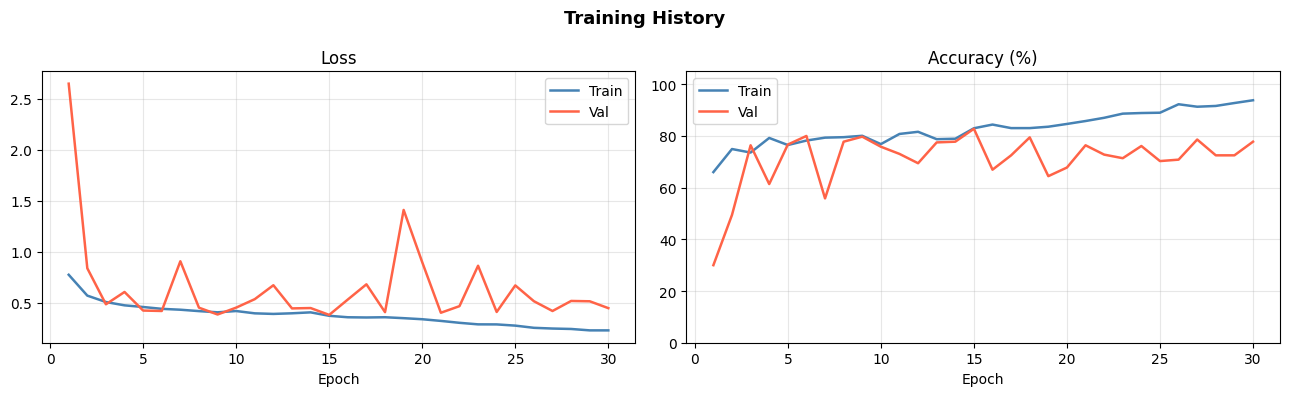

In [9]:
# Visualize the training history by plotting the training and validation loss and accuracy over epochs using Matplotlib.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep_x = range(1, EPOCHS + 1)

ax1.plot(ep_x, history['train_loss'], label='Train', color='steelblue', lw=1.8)
ax1.plot(ep_x, history['val_loss'],   label='Val',   color='tomato',    lw=1.8)
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep_x, [a*100 for a in history['train_acc']], label='Train', color='steelblue', lw=1.8)
ax2.plot(ep_x, [a*100 for a in history['val_acc']],   label='Val',   color='tomato',    lw=1.8)
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 105); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Test Accuracy: 73.61%

              precision    recall  f1-score   support

      Normal       0.57      0.55      0.56       110
 Tachycardia       0.95      1.00      0.97       122
 Bradycardia       0.66      0.64      0.65       128

    accuracy                           0.74       360
   macro avg       0.73      0.73      0.73       360
weighted avg       0.73      0.74      0.73       360



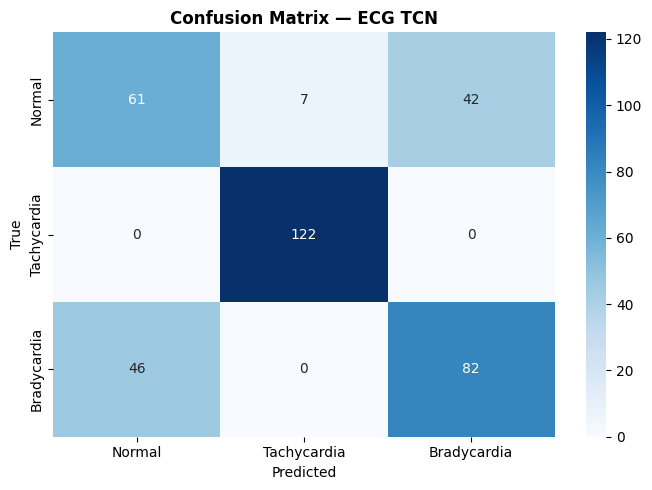

In [10]:
# Evaluate the model on the test set, print the test accuracy, 
# and display a classification report and confusion matrix to analyze performance across classes.
test_loss, test_acc = run_epoch(test_dl, train=False)
print(f'Test Accuracy: {test_acc*100:.2f}%\n')

all_preds, all_labels = [], []
model.eval()

# Iterate through the test DataLoader, compute predictions, and collect all predicted and true labels for evaluation.
with torch.no_grad():
    for xb, yb in test_dl:
        preds = model(xb.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

# Print the classification report showing precision, recall, and F1-score for each class, using the class names from CLASS_INFO.
class_names = [CLASS_INFO[i]['name'] for i in range(3)]
print(classification_report(all_labels, all_preds, target_names=class_names))

# Display the confusion matrix as a heatmap using Seaborn to visualize the performance of the model across different classes.
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — ECG TCN', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

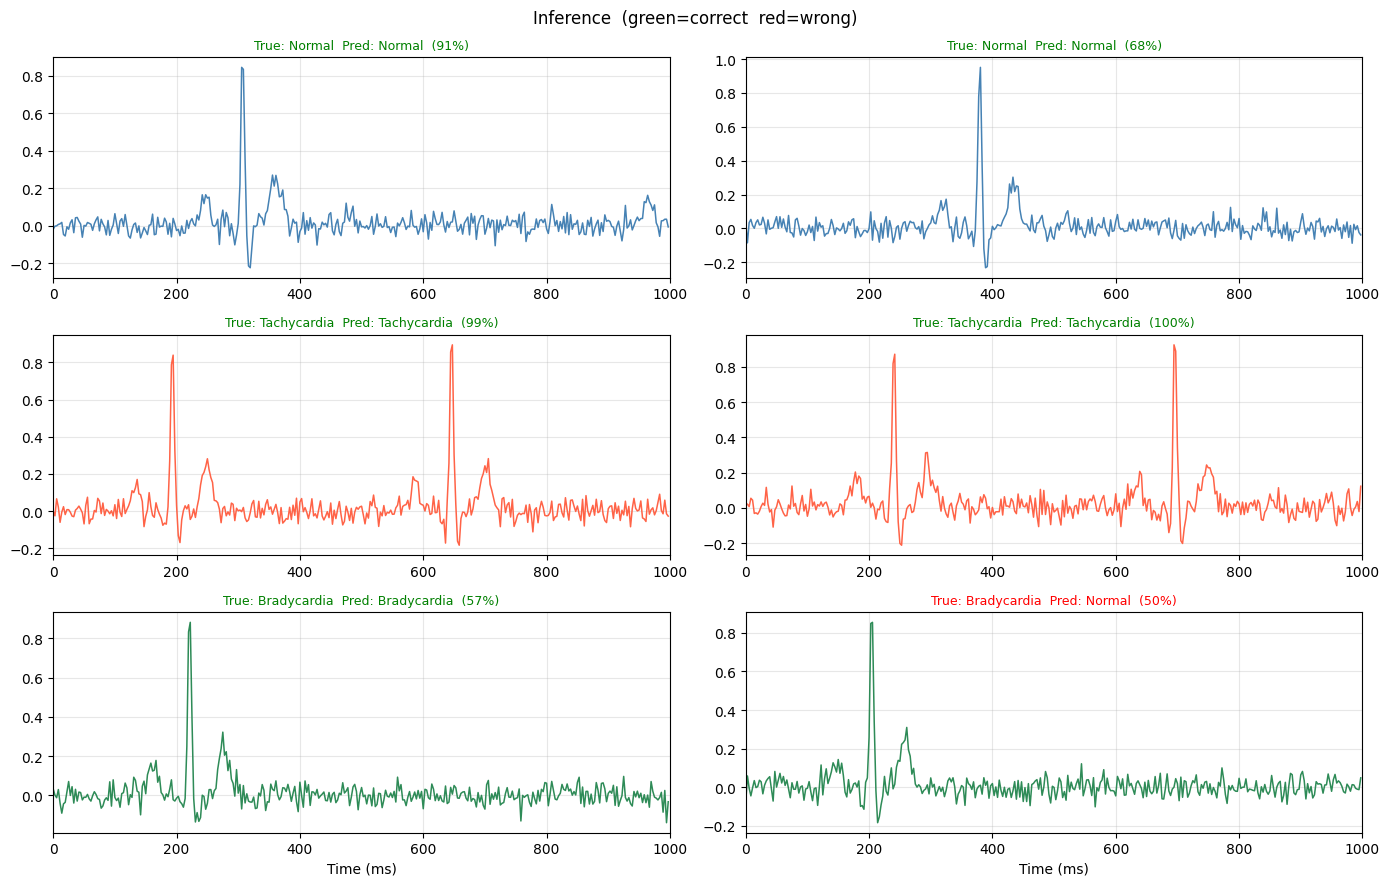

In [11]:
# Visualize sample predictions from the test set, showing the true and predicted labels along with confidence scores, 
# and color-coding correct and incorrect predictions.
rng_viz = np.random.default_rng(7)
t_axis  = np.arange(360) / FS * 1000
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

model.eval()
for label in range(3):
    indices = [i for i, l in enumerate(all_labels) if l == label]
    sampled = rng_viz.choice(indices, size=min(2, len(indices)), replace=False)
    for col, s_idx in enumerate(sampled):
        sig, true_lbl = test_ds[int(s_idx)]
        with torch.no_grad():
            logits = model(sig.unsqueeze(0).to(DEVICE))
        pred = logits.argmax(1).item()
        conf = F.softmax(logits, dim=1).max().item()
        ax   = axes[label][col]
        c    = 'green' if pred == true_lbl.item() else 'red'
        ax.plot(t_axis, sig[0].cpu().numpy(),
                color=CLASS_INFO[label]['color'], lw=1.1)
        ax.set_title(
            f"True: {CLASS_INFO[true_lbl.item()]['name']}  "
            f"Pred: {CLASS_INFO[pred]['name']}  ({conf:.0%})",
            color=c, fontsize=9)
        ax.set_xlim(0, 1000); ax.grid(alpha=0.3)
        if label == 2:
            ax.set_xlabel('Time (ms)')

plt.suptitle('Inference  (green=correct  red=wrong)', fontsize=12)
plt.tight_layout(); plt.show()